/root/miniconda3/envs/vllm/bin/python \
-m ipykernel install --user --name vllm --display-name "Python (vllm)"

In [45]:
gff_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3"
fasta_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.asm.ch.fa"
vcf_path = "/mnt/rice/default/Workspace/yangdong/ai4research/DATA/shang_data/vcf/251.SNP.final.vcf.gz"
SR_path = "/mnt/rice/default/Workspace/yangdong/ai4research/DATA/shang_data/sample_SR_B3.csv"
genes_csv = "/mnt/rice/default/Workspace/yangdong/ai4research/OneGenomeRice-seq2exp/shang_test/Chr5_28051660_28651660_genes.csv"

## 提取目标区间（Chr5: 28051660–28651660）的所有变异

用 `cyvcf2` 或 `pysam` 直接从 gz VCF 里按区间提取（流式解析，不把整个 7.8 GB 文件读进内存）。

关键参数：
- 区间：`Chr5: 28,051,660 – 28,651,660`（600 kb）
- 样本：全部 251 个个体（NH + CW）

In [46]:
import numpy as np
import pandas as pd
import gzip

vcf_path = "/mnt/rice/default/Workspace/yangdong/ai4research/DATA/shang_data/vcf/251.SNP.final.vcf.gz"

CHROM, START, END = "Chr5", 28051660, 28651660   # 目标区间（闭区间）
MAX_ALT = 16                                      # 过滤多等位位点（ALT 数 >16 的位点通常标注混乱）

# ---------- 1. 读取样本列名 ----------
with gzip.open(vcf_path, "rt") as f:
    for line in f:
        if line.startswith("#CHROM"):
            header = line.strip().split("\t")
            break
samples = header[9:]
print(f"样本数: {len(samples)}")

# ---------- 2. 流式提取区间内变异 ----------
rows = []
with gzip.open(vcf_path, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        cols = line.strip().split("\t")
        chrom, pos = cols[0], int(cols[1])
        if chrom != CHROM or not (START <= pos <= END):
            continue
        ref, alt = cols[3], cols[4]
        if len(alt.split(",")) > MAX_ALT:
            continue
        fmt_keys = cols[8].split(":")              # 每个样本的 FORMAT
        gt_idx = fmt_keys.index("GT") if "GT" in fmt_keys else None
        gts = []
        for g in cols[9:]:
            if gt_idx is None:
                gts.append(None)
                continue
            gt = g.split(":")[gt_idx]
            # 0/0 -> 0, 0/1/1/1 -> 1, ./. -> NaN
            if gt in (".", "./.", ".|."):
                gts.append(np.nan)
            elif gt.count("1") == 0:
                gts.append(0)
            else:
                gts.append(1)
        rows.append([chrom, pos, ref, alt] + gts)

df = pd.DataFrame(rows, columns=["CHROM", "POS", "REF", "ALT"] + samples)
print(f"区间 {CHROM}:{START}-{END} 内变异数: {len(df)}")
print(f"df 形状: {df.shape}")
df.head()

样本数: 251
区间 Chr5:28051660-28651660 内变异数: 7415
df 形状: (7415, 255)


,CHROM,POS,REF,ALT,NH001,NH002,NH003,NH005,NH006,NH007,...,NH277,NH278,NH279,NH280,NH281,NH282,NH283,NH284,NH285,NH286
0,Chr5,28051703,A,T,0.0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,Chr5,28051803,C,G,0.0,0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Chr5,28052596,G,T,0.0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
3,Chr5,28052604,C,T,1.0,0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Chr5,28052899,C,"T,*",0.0,0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [47]:
df.head()

,CHROM,POS,REF,ALT,NH001,NH002,NH003,NH005,NH006,NH007,...,NH277,NH278,NH279,NH280,NH281,NH282,NH283,NH284,NH285,NH286
0,Chr5,28051703,A,T,0.0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,Chr5,28051803,C,G,0.0,0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Chr5,28052596,G,T,0.0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
3,Chr5,28052604,C,T,1.0,0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Chr5,28052899,C,"T,*",0.0,0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [48]:
# ---------- 3. 计算每个位点的 MAF 并按 MAF 从大到小排序 ----------
# 基因型编码（来自 VCF 提取 cell）: 0 = ref 纯合(0/0), 1 = 携带 alt(0/1 或 1/1), NaN = 缺失
# 注意：必须按 samples 列表选基因型列，否则 df 中已有的 MAF/N_called 等元数据列会被误当基因型
gt = df[samples].astype(float)

n_called = gt.count(axis=1)                        # 有基因型的个体数
n_alt    = gt.sum(axis=1, skipna=True)             # 携带 alt 的个体数
af_alt   = n_alt / n_called                        # alt 携带率（≈alt 等位频率，见下方注意）
maf      = np.minimum(af_alt, 1 - af_alt)          # MAF = min(alt 频率, ref 频率)

df["N_called"] = n_called.values
df["N_alt"]    = n_alt.values
df["AF_alt"]   = af_alt.values
df["MAF"]      = maf.values

# 按 MAF 从大到小排序（AF_alt=0 或 1 的固定位点 MAF=0 排在最后）
df = df.sort_values("MAF", ascending=False).reset_index(drop=True)

print(f"位点数: {len(df)}")
print(f"MAF 分布: min={df['MAF'].min():.4f}  median={df['MAF'].median():.4f}  max={df['MAF'].max():.4f}")
print("\nTop 20 高 MAF 位点：")
print(df[["CHROM", "POS", "REF", "ALT", "N_called", "N_alt", "AF_alt", "MAF"]].head(20).to_string())

# 注：当前基因型是 0/1 二值（携带 alt 与否），AF_alt 实际是「携带者频率」。
# 严格等位基因频率需按剂量 0/0→0, 0/1→0.5, 1/1→1 重新提取 VCF；需要的话我再补。


位点数: 7415
MAF 分布: min=0.0451  median=0.2240  max=0.5000

Top 20 高 MAF 位点：
   CHROM       POS REF ALT  N_called  N_alt    AF_alt       MAF
0   Chr5  28150394   G   T       238  119.0  0.500000  0.500000
1   Chr5  28570160   G   T       222  111.0  0.500000  0.500000
2   Chr5  28591303   G   A       230  115.0  0.500000  0.500000
3   Chr5  28413906   T   C       250  125.0  0.500000  0.500000
4   Chr5  28413905   C   A       250  125.0  0.500000  0.500000
5   Chr5  28515522   T   A       251  126.0  0.501992  0.498008
6   Chr5  28512101   C   T       251  126.0  0.501992  0.498008
7   Chr5  28527192   G   C       251  125.0  0.498008  0.498008
8   Chr5  28520658   G   A       251  126.0  0.501992  0.498008
9   Chr5  28537503   G   A       251  126.0  0.501992  0.498008
10  Chr5  28532593   C   T       251  125.0  0.498008  0.498008
11  Chr5  28461449   G   C       251  125.0  0.498008  0.498008
12  Chr5  28461573   T   C       251  125.0  0.498008  0.498008
13  Chr5  28510647   G   A    

In [49]:
# ---------- 4. 构建 df_sample：以每个变异位点为中心，左右各 padding 16 kb ----------
PAD = 16384                      # 单侧 padding = 16 kb
WIN = 2 * PAD                    # 窗口总长 32768，与模型 max_length 一致

# VCF 的 POS 是 1-based；pyfaidx 取序列是 0-based 半开区间 [start, end)
# 窗口以 POS 为中心：0-based start = POS - 1 - PAD，end = start + WIN
df_sample = df[["CHROM", "POS", "REF", "ALT", "MAF"]].copy()
df_sample["start"] = df_sample["POS"] - 1 - PAD        # 0-based，位点左侧 16 kb
df_sample["end"]   = df_sample["start"] + WIN          # 0-based 开区间，位点右侧 16 kb
df_sample["center_offset"] = PAD                       # 位点(REF 首碱基)在窗口内的 0-based 偏移

# 边界检查（Chr5 全长约 29.8 Mb，本区间 28.05–28.65 Mb，正常不会越界）
if (df_sample["start"] < 0).any():
    print(f"⚠️ 有 {int((df_sample['start'] < 0).sum())} 个位点窗口越界(start<0)，已保留待处理")

# 把每个样本的基因型并入 df_sample（df 已按 MAF 降序、索引已重置，行序一致）
gt_cols = [c for c in df.columns
           if c not in ("CHROM", "POS", "REF", "ALT", "MAF", "N_called", "N_alt", "AF_alt")]
df_sample = pd.concat([df_sample, df[gt_cols].reset_index(drop=True)], axis=1)

print(f"df_sample 形状: {df_sample.shape}  (位点数 × 列数)")
print(f"窗口长度唯一值: {(df_sample['end'] - df_sample['start']).unique()}")
print(df_sample[["CHROM", "POS", "REF", "ALT", "MAF", "start", "end", "center_offset"]].head(10).to_string())


df_sample 形状: (7415, 259)  (位点数 × 列数)
窗口长度唯一值: [32768]
  CHROM       POS REF ALT       MAF     start       end  center_offset
0  Chr5  28150394   G   T  0.500000  28134009  28166777          16384
1  Chr5  28570160   G   T  0.500000  28553775  28586543          16384
2  Chr5  28591303   G   A  0.500000  28574918  28607686          16384
3  Chr5  28413906   T   C  0.500000  28397521  28430289          16384
4  Chr5  28413905   C   A  0.500000  28397520  28430288          16384
5  Chr5  28515522   T   A  0.498008  28499137  28531905          16384
6  Chr5  28512101   C   T  0.498008  28495716  28528484          16384
7  Chr5  28527192   G   C  0.498008  28510807  28543575          16384
8  Chr5  28520658   G   A  0.498008  28504273  28537041          16384
9  Chr5  28537503   G   A  0.498008  28521118  28553886          16384


In [50]:
test = df_sample.loc[0, ["CHROM", "POS", "REF", "ALT", "MAF", "start", "end", "center_offset"]].tolist()
test

['Chr5',
 np.int64(28150394),
 'G',
 'T',
 np.float64(0.5),
 np.int64(28134009),
 np.int64(28166777),
 np.int64(16384)]

In [51]:
import sys

sys.path.append('/mnt/rice/default/Workspace/yangdong/ai4research/OneGenomeRice-seq2exp/old0907/')

In [52]:
import os
import sys
import json
import time
import argparse
import random
import glob
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from transformers import AutoTokenizer, AutoConfig
from safetensors.torch import load_file
import pyfaidx
import dotenv
from pathlib import Path
import re

# 导入自定义模块（需确保 src 目录在 Python 路径中）
from src.dataset import MultiTrackDataset, load_fasta_sequence
from src.viewer import DatasetViewer, ResultsViewer
from src.model import GenOmics, load_finetuned_model

# 设置中文字体（根据系统环境调整）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [53]:
class MultiTrackPredictor:
    def __init__(self, fasta_path: str, base_model_path: str, sft_ckpt_path: str,
                 tokenizer_path: str, use_flash_attn: bool,
                 index_stat_path: str = None, index_stat: dict = None,
                 **kwargs):
        self.fasta = pyfaidx.Fasta(fasta_path)
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        
        # 支持直接传 dict 或从 JSON 文件读取
        if index_stat is not None:
            stat_data = index_stat
        elif index_stat_path is not None:
            stat_data = json.load(open(index_stat_path, "r"))
        else:
            raise ValueError("必须提供 index_stat（dict）或 index_stat_path（文件路径）")
        
        self.model = load_finetuned_model(
            model_class = GenOmics,
            model_path = base_model_path,
            ckpt_path = sft_ckpt_path,
            use_flash_attn = use_flash_attn,
            device = "cuda:1",     # GPU0 被其他任务占满（100%），GPU1 空闲，固定用 cuda:1
            model_init_kwargs={"index_stat": stat_data, **kwargs}
        )
        print("✔️ Model loaded successfully")
        print(self.model)
        self.model.eval()

    # ---- 原有 __init__（保留注释） ----
    # def __init__(self, fasta_path, base_model_path, sft_ckpt_path,
    #              tokenizer_path, use_flash_attn, index_stat_path, **kwargs):
    #     ...
    #     self.model = load_finetuned_model(...
    #         model_init_kwargs={"index_stat": json.load(open(index_stat_path, "r")), ...})
    #     ...

    def predict(self, chrom: str, start: int, end: int, biosample_names: list = None) -> dict:
            predict_sequence = load_fasta_sequence(self.fasta, chrom, start, end)
            inputs = self.tokenizer(
                predict_sequence,
                return_tensors="pt",
                padding=False,
                truncation=True,
                max_length=32768,
                add_special_tokens=False
            ).to("cuda:1")        # 原为 .to("cuda")（=GPU0），已改 cuda:1，原因同上
            with torch.no_grad():
                start_time = time.time()
                result = self.model.predict(inputs['input_ids'],
                                            biosample_names=biosample_names)
                time_taken = time.time() - start_time
                torch.cuda.empty_cache()
            print(f"Inference time: {time_taken:.2f} s.")
            return {
                'sequence': predict_sequence,
                'position': (chrom, start, end),
                'values': result
            }
    def predict2(self, chrom: str, start: int, end: int, seq: str, biosample_names: list = None) -> dict:
        sequence = pyfaidx.Fasta(seq)
        predict_sequence = str(sequence[0][:])
        inputs = self.tokenizer(
            predict_sequence,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=32768,
            add_special_tokens=False
        ).to("cuda:1")        # 原为 .to("cuda")（=GPU0），已改 cuda:1，原因同上
        with torch.no_grad():
            start_time = time.time()
            result = self.model.predict(inputs['input_ids'],
                                        biosample_names = biosample_names)
            time_taken = time.time() - start_time
            torch.cuda.empty_cache()
        print(f"Inference time: {time_taken:.2f} s.")
        return {
            'sequence': predict_sequence,
            'position': (chrom, start, end),
            'values': result
        }

In [54]:
class Args:
    pass

args = Args()
args.biosample_names = "leaf_salt"

# 固定配置（请根据实际情况修改）
fasta_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.asm.ch.fa"
base_model_dir = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/rice_1B_stage2_8k_hf"
sft_ckpt_path = "/mnt/rice/default/Workspace/yangdong/ai4research/OneGenomeRice-seq2exp/old0907/output/202609081121/checkpoint-380/model.safetensors"
index_stat_path = "/mnt/rice/default/Workspace/yangdong/ai4research/OneGenomeRice-seq2exp/old0907/data/indices/train_leaf_ck_leaf_salt_NH001_multitrack/index_stat.json"

In [55]:
# 设置随机种子
seed = 42
random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
print(f"✅ Random seed set to {seed}")

# 初始化预测器
predictor = MultiTrackPredictor(
    fasta_path=fasta_path,
    base_model_path=base_model_dir,
    sft_ckpt_path=sft_ckpt_path,
    tokenizer_path=base_model_dir,
    use_flash_attn=True,
    index_stat_path=index_stat_path,
    # index_stat=index_stat,
    proj_dim=1024,
    num_downsamples=4,
    bottleneck_dim=1536
)

✅ Random seed set to 42


2026-09-16 12:09:49,723 - INFO - ⚠️ 使用 Flash Attention 2 需要 torch.float16 或 torch.bfloat16，已自动设置为 torch.bfloat16


✔️ Model loaded successfully
GenOmics(
  (base): MixtralModel(
    (embed_tokens): Embedding(128, 1024, padding_idx=14)
    (layers): ModuleList(
      (0-11): 12 x MixtralDecoderLayer(
        (self_attn): MixtralAttention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1024, out_features=512, bias=False)
          (v_proj): Linear(in_features=1024, out_features=512, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
        )
        (block_sparse_moe): MixtralSparseMoeBlock(
          (gate): Linear(in_features=1024, out_features=8, bias=False)
          (experts): ModuleList(
            (0-7): 8 x MixtralBlockSparseTop2MLP(
              (w1): Linear(in_features=1024, out_features=4096, bias=False)
              (w2): Linear(in_features=4096, out_features=1024, bias=False)
              (w3): Linear(in_features=1024, out_features=4096, bias=False)
              (act_fn): SiLUAc

In [56]:
chrom = test[0]  # 取第一个变异位点的 CHROM 作为目标染色体
window_start = test[5]  # 取第一个变异位点的 start 作为窗口起始位置
window_end = window_start + 32768  # 窗口长度为 32768

In [57]:
# ref_predict = predictor.predict(chrom=chrom, start=window_start, end=window_end,
#                                 biosample_names=args.biosample_names)

In [58]:
# ref_predict

In [59]:
# ref_predict['values']['total_RNA-seq_+'].keys()

In [ ]:
# =====================================================================
# 逐位点计算：alt 窗口 → 预测 → 窗口/基因区 log2FC + 变异位点注释
# 先跑 MAF 前 5 的位点（df_sample 已按 MAF 降序）
# =====================================================================
import re
from scipy.stats import spearmanr

# ---------- 1. 读取 GFF，建立「基因 / CDS」区间表（Chr5） ----------
gff_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3"
feats = []
with open(gff_path) as f:
    for line in f:
        if line.startswith("#"):
            continue
        c = line.strip().split("\t")
        if len(c) < 9 or c[0] != "Chr5":
            continue
        ftype = c[2]
        if ftype not in ("gene", "CDS"):
            continue
        m = re.search(r"ID=([^;]+)", c[8])
        # 【修复】CDS 行额外解析 Parent（转录本 id，如 LOC_Os05g49720.1），
        # 去掉 .N 后缀映射回 gene id（LOC_Os05g49720），
        # 使 annotate_variant 对 CDS 位点返回基因 id，与 gene_log2FCs 的 id 格式一致
        gene_id = ""
        if ftype == "CDS":
            pm = re.search(r"Parent=([^;]+)", c[8])
            gene_id = re.sub(r"\.\d+$", "", pm.group(1)) if pm else ""
        feats.append((ftype, int(c[3]), int(c[4]), m.group(1) if m else "", gene_id))

gff_df = pd.DataFrame(feats, columns=["type", "start", "end", "id", "gene_id"])  # 1-based 闭区间

genes = gff_df[gff_df["type"] == "gene"][["start", "end", "id"]].reset_index(drop=True)
cds   = gff_df[gff_df["type"] == "CDS"][["start", "end", "id", "gene_id"]].reset_index(drop=True)
print(f"Chr5 gene 数: {len(genes)}, CDS 数: {len(cds)}")

# 合并同一基因的所有 CDS 区间（该基因 CDS 覆盖范围 = min..max）
# 【修复】按 gene_id 分组（原来按 CDS id 分组，CDS 位点注释成 LOC_...:cds_N 匹配不到基因）
cds_by_gene = cds.groupby("gene_id").agg(start=("start", "min"), end=("end", "max"))

# ---------- 2. 注释函数：变异位点落在什么区域 ----------
def annotate_variant(pos: int):
    """返回 (region, gene_id, distance)：
    region: 'CDS' / 'gene_noncoding'(基因内但非CDS) / 'intergenic'
    落在基因外 → 最近基因及其距离（bp）
    注：CDS 命中时返回的也是 gene id（LOC_Os05gXXXXX），不再是 CDS 子 id
    """
    # 2.1 是否在 CDS 内（基因→CDS 区间，注意一个基因可能有多个 CDS，这里按合并区间判）
    in_cds = cds_by_gene[(cds_by_gene["start"] <= pos) & (pos <= cds_by_gene["end"])]
    if len(in_cds):
        g = in_cds.index[0]
        return "CDS", g, 0

    # 2.2 是否在基因内（gene 区间，含内含子/UTR 等非编码部分）
    in_gene = genes[(genes["start"] <= pos) & (pos <= genes["end"])]
    if len(in_gene):
        g = in_gene["id"].iloc[0]
        return "gene_noncoding", g, 0

    # 2.3 基因间区 → 最近基因（按距离）
    # 左侧最近基因：start <= pos 的最后一个；右侧最近：end >= pos 的第一个
    left  = genes[genes["end"] < pos]
    right = genes[genes["start"] > pos]
    d_left  = pos - left["end"].max()   if len(left)  else np.inf
    d_right = right["start"].min() - pos if len(right) else np.inf
    if d_left <= d_right:
        g = left.loc[left["end"].idxmax(), "id"]
        return "intergenic", g, int(d_left)
    else:
        g = right.loc[right["start"].idxmin(), "id"]
        return "intergenic", g, int(d_right)

Chr5 gene 数: 4572, CDS 数: 24420


In [61]:
df_sample

,CHROM,POS,REF,ALT,MAF,start,end,center_offset,NH001,NH002,...,NH277,NH278,NH279,NH280,NH281,NH282,NH283,NH284,NH285,NH286
0,Chr5,28150394,G,T,0.500000,28134009,28166777,16384,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Chr5,28570160,G,T,0.500000,28553775,28586543,16384,0.0,0,...,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,Chr5,28591303,G,A,0.500000,28574918,28607686,16384,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chr5,28413906,T,C,0.500000,28397521,28430289,16384,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Chr5,28413905,C,A,0.500000,28397520,28430288,16384,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7410,Chr5,28111886,G,T,0.051793,28095501,28128269,16384,0.0,0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7411,Chr5,28119908,A,G,0.051793,28103523,28136291,16384,0.0,0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7412,Chr5,28302650,T,C,0.051793,28286265,28319033,16384,0.0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7413,Chr5,28169576,C,G,0.050420,28153191,28185959,16384,0.0,0,...,1.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,1.0,0.0


In [62]:
# =====================================================================
# 全量逐位点推理：ref/alt 窗口 → 预测 → 窗口/基因区 log2FC + 位点注释
# - 支持多碱基 REF/ALT（indel / MNP / 多等位：变长替换 + 一致性校验）
# - 与参考不一致的位点跳过（记入日志），不再中断整个循环
# - 日志单独写入 run_20k.log；notebook 只每 1000 个打印一次进度
# =====================================================================
import logging, datetime

# 日志：单独文件 + 控制台（默认只显示 INFO 及以上）
LOG_FILE = "run_20k.log"
logger = logging.getLogger("variant_effect")
logger.setLevel(logging.INFO)
logger.handlers.clear()          # 避免 notebook 重复执行时 handler 叠加
_fh = logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8")
_fh.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
logger.addHandler(_fh)
_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter("%(message)s"))
logger.addHandler(_sh)

# ---------- 3. 目标位点：MAF 前 20000 ----------
top_n = 20000
sub = df_sample.head(top_n).copy()

# ---------- 4. 逐位点推理 ----------
results = []
ASSAY = "total_RNA-seq_+"
n_skipped = {"ref_mismatch": 0, "multi_allelic": 0, "too_long": 0}
t0 = datetime.datetime.now()
logger.info(f"===== 开始推理 {len(sub)} 个位点 @ {t0:%Y-%m-%d %H:%M:%S} =====")

for idx, row in sub.iterrows():
    chrom  = row["CHROM"]
    pos    = int(row["POS"])
    ref_b  = row["REF"]
    alt_b  = row["ALT"]
    ws, we = int(row["start"]), int(row["end"])
    off    = int(row["center_offset"])          # 位点在窗口内的 0-based 偏移（=16384）
    maf    = row["MAF"]

    # ---- 4.0 前置检查：多等位 / 过长 ALT 直接跳过（VCF 提取时已按 MAX_ALT 过滤，这里再兜底） ----
    if "," in str(alt_b):
        n_skipped["multi_allelic"] += 1
        logger.warning(f"[{idx+1}] 跳过多等位位点 {chrom}:{pos} REF={ref_b} ALT={alt_b}")
        continue
    if len(str(alt_b)) > 64:
        n_skipped["too_long"] += 1
        logger.warning(f"[{idx+1}] 跳过过长 ALT({len(str(alt_b))}bp) {chrom}:{pos} REF={ref_b} ALT={alt_b}")
        continue

    # 4.1 ref 序列（直接从 fasta 取）+ alt 序列（变长替换：支持 indel/MNP/多碱基）
    #     REF/ALT 长度不相等也能正确替换，前提是参考序列该位置与 REF 一致
    seq_ref = str(predictor.fasta[chrom][ws:we])                      # 长度 32768
    ref_b = str(ref_b)
    alt_b = str(alt_b)
    if seq_ref[off:off + len(ref_b)] != ref_b:
        n_skipped["ref_mismatch"] += 1
        logger.warning(f"[{idx+1}] 参考不一致，跳过 {chrom}:{pos} "
                       f"fasta={seq_ref[off:off+len(ref_b)]} REF={ref_b}")
        continue
    seq_alt = seq_ref[:off] + alt_b + seq_ref[off + len(ref_b):]     # 变长替换

    # 4.2 推理（复用 predictor 的 tokenize + model.predict）
    def run(seq):
        inputs = predictor.tokenizer(seq, return_tensors="pt", padding=False,
                                     truncation=True, max_length=32768,
                                     add_special_tokens=False).to("cuda:1")
        with torch.no_grad():
            out = predictor.model.predict(inputs["input_ids"],
                                          biosample_names=args.biosample_names)
        return out[ASSAY][args.biosample_names].float().cpu().numpy().flatten()  # [L]

    y_ref = run(seq_ref)
    y_alt = run(seq_alt)
    torch.cuda.empty_cache()

    # 4.3 窗口整体 log2FC（均值比）
    eps = 1e-6
    log2fc_win = np.log2((y_alt.mean() + eps) / (y_ref.mean() + eps))

    # 4.4 基因区域 log2FC：落在窗口内的所有基因（位点所在窗口 ± 基因重叠）
    #     基因区 = 与窗口 [ws, we) 重叠的 gene 区间（用 1-based 转换比较）
    win_genes = genes[(genes["start"] <= we) & (genes["end"] >= ws + 1)]
    gene_rows = []
    for _, g in win_genes.iterrows():
        gs, ge, gid = g["start"], g["end"], g["id"]
        s = max(ws + 1, gs)            # 交集（1-based）
        e = min(we, ge)
        if s > e:
            continue
        lo, hi = s - 1 - ws, e - ws    # 窗口内 0-based 索引 [lo, hi)
        exp_ref = y_ref[lo:hi].sum()
        exp_alt = y_alt[lo:hi].sum()
        gene_rows.append({
            "gene": gid, "gene_start": gs, "gene_end": ge,
            "overlap_bp": hi - lo,
            "exp_ref": float(exp_ref), "exp_alt": float(exp_alt),
            "log2FC": float(np.log2((exp_alt + eps) / (exp_ref + eps))),
        })

    # 4.5 变异位点注释
    region, near_gene, dist = annotate_variant(pos)

    results.append({
        "CHROM": chrom, "POS": pos, "REF": ref_b, "ALT": alt_b, "MAF": maf,
        "window_start": ws, "window_end": we,
        "log2FC_window": float(log2fc_win),
        "region": region, "nearest_gene": near_gene, "dist_to_gene": dist,
        "n_genes_in_window": len(gene_rows),
        "genes": gene_rows,
    })
    # 详细日志 → run_20k.log；notebook 只每 1000 个打一次进度
    logger.info(f"[{idx+1}/{top_n}] {chrom}:{pos} {ref_b}>{alt_b} MAF={maf:.3f} "
                f"region={region} near={near_gene} dist={dist} "
                f"log2FC_win={log2fc_win:+.4f} n_genes={len(gene_rows)}")
    if (idx + 1) % 1000 == 0:
        el = (datetime.datetime.now() - t0).total_seconds()
        logger.info(f"---- 进度 {idx+1}/{top_n} 用时 {el:.0f}s "
                    f"({el/(idx+1)*1000:.1f}s/千) 跳过={sum(n_skipped.values())} ----")

logger.info(f"===== 完成 {len(results)} 个位点，跳过 {sum(n_skipped.values())} 个 "
            f"({n_skipped}) @ {datetime.datetime.now():%Y-%m-%d %H:%M:%S} =====")


# ---------- 5. 汇总结果 ----------
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != "genes"} for r in results])
# 新增：最近基因（nearest_gene）的 log2FC
# 从窗口内基因列表中按 ID 匹配；若最近基因不在窗口内（intergenic 且距离>窗口边界）则为 NaN
res_df["nearest_gene_log2FC"] = [
    next((g["log2FC"] for g in r["genes"] if g["gene"] == r["nearest_gene"]), np.nan)
    for r in results
]
res_df["gene_log2FCs"] = [";".join(f"{g['gene']}:{g['log2FC']:+.3f}" for g in r["genes"]) for r in results]



print("\n===== 位点 × 窗口/基因 log2FC 汇总 =====")
print(f"完成 {len(results)} / {top_n} 个位点（跳过 {sum(n_skipped.values())} 个）")
print(f"详细日志: {LOG_FILE}")

# # 保存
# res_df.to_csv("variant_effect_top20000.csv", index=False)
# print("\n已保存 variant_effect_top20000.csv")

===== 开始推理 7415 个位点 @ 2026-09-16 12:10:02 =====
2026-09-16 12:10:02,576 - INFO - ===== 开始推理 7415 个位点 @ 2026-09-16 12:10:02 =====


/root/miniconda3/envs/vllm/lib/python3.12/site-packages/transformers/models/mixtral/modeling_mixtral.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
/root/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with e


===== 位点 × 窗口/基因 log2FC 汇总 =====
完成 7267 / 20000 个位点（跳过 148 个）
详细日志: run_20k.log


In [63]:
res_df

,CHROM,POS,REF,ALT,MAF,window_start,window_end,log2FC_window,region,nearest_gene,dist_to_gene,n_genes_in_window,nearest_gene_log2FC,gene_log2FCs
0,Chr5,28150394,G,T,0.500000,28134009,28166777,0.001002,intergenic,LOC_Os05g49100,4299,4,0.002771,LOC_Os05g49080:+0.000;LOC_Os05g49090:+0.000;LO...
1,Chr5,28570160,G,T,0.500000,28553775,28586543,-0.001944,intergenic,LOC_Os05g49780,2248,5,-0.022595,LOC_Os05g49770:+0.000;LOC_Os05g49780:-0.023;LO...
2,Chr5,28591303,G,A,0.500000,28574918,28607686,-0.000004,gene_noncoding,LOC_Os05g49820,0,8,0.000062,LOC_Os05g49780:+0.000;LOC_Os05g49790:+0.000;LO...
3,Chr5,28413906,T,C,0.500000,28397521,28430289,0.001007,gene_noncoding,LOC_Os05g49540,0,5,0.003148,LOC_Os05g49520:+0.000;LOC_Os05g49530:+0.000;LO...
4,Chr5,28413905,C,A,0.500000,28397520,28430288,0.000198,gene_noncoding,LOC_Os05g49540,0,5,-0.003064,LOC_Os05g49520:-0.029;LOC_Os05g49530:+0.027;LO...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,Chr5,28111886,G,T,0.051793,28095501,28128269,0.000983,intergenic,LOC_Os05g49020,734,7,-0.001812,LOC_Os05g48990:+0.005;LOC_Os05g49000:+0.001;LO...
7263,Chr5,28119908,A,G,0.051793,28103523,28136291,-0.007360,CDS,LOC_Os05g49030.1:cds_4,0,10,NaN,LOC_Os05g48990:-0.002;LOC_Os05g49000:-0.012;LO...
7264,Chr5,28302650,T,C,0.051793,28286265,28319033,0.000864,intergenic,LOC_Os05g49330,1156,9,0.000000,LOC_Os05g49300:+0.000;LOC_Os05g49310:+0.000;LO...
7265,Chr5,28169576,C,G,0.050420,28153191,28185959,0.000852,intergenic,LOC_Os05g49110,680,4,-0.000588,LOC_Os05g49100:+0.006;LOC_Os05g49110:-0.001;LO...


In [66]:
# =====================================================================
# 【修复】res_df 的 nearest_gene：CDS 位点原来是 LOC_...:cds_N 子 id
# 改为统一映射回基因 id（LOC_Os05gXXXXX），与 gene_log2FCs 的 id 格式一致
# 这样 nearest_gene_log2FC 在 CDS 位点也能正确匹配，不需要重跑推理
# =====================================================================
# 从 gene_log2FCs 字符串中拆出 (gene -> log2FC) 映射，用于重算 nearest_gene_log2FC
def _gene_fc_map(s):
    d = {}
    if pd.isna(s):
        return d
    for entry in str(s).split(";"):
        try:
            gname, gfc = entry.rsplit(":", 1)
            d[gname] = float(gfc)
        except ValueError:
            continue
    return d

res_df["gene_fc_map"] = res_df["gene_log2FCs"].map(_gene_fc_map)

# CDS 位点：nearest_gene 形如 "LOC_Os05gXXXXX.N:cds_M" → 去 .N:cds_M 得到基因 id
def _norm_nearest(g):
    if pd.isna(g):
        return g
    s = str(g)
    return re.sub(r"\.\d+:cds_\d+$", "", s)

res_df["nearest_gene"] = res_df["nearest_gene"].map(_norm_nearest)

# 用基因 id 重新匹配 nearest_gene_log2FC
res_df["nearest_gene_log2FC"] = [
    r["gene_fc_map"].get(r["nearest_gene"], np.nan) for _, r in res_df.iterrows()
]
res_df = res_df.drop(columns=["gene_fc_map"])

print("nearest_gene 修复完成，CDS 位点示例：")
print(res_df[res_df["region"] == "CDS"][["POS", "REF", "ALT", "nearest_gene", "nearest_gene_log2FC"]].head(10).to_string())

# 重新保存
res_df.to_csv("variant_effect_top20000.csv", index=False)
print("\n已更新 variant_effect_top20000.csv")


nearest_gene 修复完成，CDS 位点示例：
         POS REF ALT    nearest_gene  nearest_gene_log2FC
6   28512101   C   T  LOC_Os05g49720                0.003
15  28245442   C   T  LOC_Os05g49230               -0.001
24  28349190   C   T  LOC_Os05g49450                0.025
26  28508059   G   A  LOC_Os05g49710                0.001
46  28506512   C   T  LOC_Os05g49710                0.003
58  28511813   A   G  LOC_Os05g49720                0.022
64  28535634   C   G  LOC_Os05g49740                0.017
73  28417028   T   C  LOC_Os05g49540                0.001
80  28511824   A   C  LOC_Os05g49720                0.011
96  28506613   C   T  LOC_Os05g49710                0.003

已更新 variant_effect_top20000.csv


In [67]:
# =====================================================================
# 【筛选 1/4】单变异排序：找最近基因效应最强（|log2FC| 最大）的位点
# =====================================================================
res_df["abs_nearest_log2FC"] = res_df["nearest_gene_log2FC"].abs()

top_effect = res_df.sort_values("abs_nearest_log2FC", ascending=False).head(30)
print("=== 最近基因效应最强的 30 个位点 ===")
print(top_effect[["POS", "REF", "ALT", "MAF", "region", "nearest_gene",
                  "dist_to_gene", "nearest_gene_log2FC", "log2FC_window"]].to_string())

print(f"\n|nearest_gene_log2FC| > 0.01 的位点数: {(res_df['abs_nearest_log2FC'] > 0.01).sum()} / {len(res_df)}")
print(f"|nearest_gene_log2FC| > 0.05 的位点数: {(res_df['abs_nearest_log2FC'] > 0.05).sum()} / {len(res_df)}")


=== 最近基因效应最强的 30 个位点 ===
           POS REF ALT       MAF          region    nearest_gene  dist_to_gene  nearest_gene_log2FC  log2FC_window
1936  28360713   G   T  0.341991  gene_noncoding  LOC_Os05g49480             0                1.542       0.107363
1473  28443967   G   A  0.366534             CDS  LOC_Os05g49580             0                0.562       0.007780
5450  28301151   C   T  0.083665             CDS  LOC_Os05g49330             0                0.419       0.001839
3968  28253664   T   C  0.207171             CDS  LOC_Os05g49240             0                0.379       0.002763
2983  28444095   A   C  0.258964             CDS  LOC_Os05g49580             0                0.343       0.000990
4624  28486344   C   T  0.124000             CDS  LOC_Os05g49660             0                0.337      -0.001178
4930  28498038   A   G  0.096386  gene_noncoding  LOC_Os05g49690             0                0.316      -0.006781
4625  28486296   C   T  0.124000             CDS  LOC_O

In [68]:
# =====================================================================
# 【筛选 2/4】基因聚合：谁被多个独立位点同时影响且方向一致（最可靠的信号）
# =====================================================================
gene_effects = []
for _, r in res_df.iterrows():
    if pd.isna(r["gene_log2FCs"]):
        continue
    for entry in str(r["gene_log2FCs"]).split(";"):
        try:
            gname, gfc = entry.rsplit(":", 1)
            gene_effects.append({"POS": r["POS"], "REF": r["REF"], "ALT": r["ALT"],
                                 "MAF": r["MAF"], "gene": gname, "log2FC": float(gfc)})
        except ValueError:
            continue
ge = pd.DataFrame(gene_effects)

# 对每个基因：位点数、效应均值、方向一致性、|效应|>0.01 的位点数、最大 |效应|
agg = ge.groupby("gene").agg(
    n_variants=("log2FC", "count"),
    mean_log2FC=("log2FC", "mean"),
    strong_n=("log2FC", lambda x: (x.abs() > 0.01).sum()),
    max_abs=("log2FC", lambda x: x.abs().max()),
    frac_up=("log2FC", lambda x: (x > 0).mean()),
).sort_values("strong_n", ascending=False)

print("=== 被 ≥2 个位点且 |log2FC|>0.01 影响的基因 TOP30 ===")
print(agg[agg["strong_n"] >= 2].head(30).to_string())

# 保存长表（可选）
# ge.to_csv("gene_effects_long.csv", index=False)


=== 被 ≥2 个位点且 |log2FC|>0.01 影响的基因 TOP30 ===
                n_variants  mean_log2FC  strong_n  max_abs   frac_up
gene                                                                
LOC_Os05g49100         683     0.001343       316    0.200  0.392387
LOC_Os05g49040         663     0.001131       296    0.259  0.395173
LOC_Os05g49164         478     0.000519       274    0.132  0.397490
LOC_Os05g49740         521    -0.000645       272    0.116  0.364683
LOC_Os05g49690         658    -0.000673       272    0.316  0.331307
LOC_Os05g49684         608    -0.001801       226    0.299  0.348684
LOC_Os05g49790         460     0.000115       225    0.121  0.402174
LOC_Os05g49090         773     0.000604       224    0.071  0.412678
LOC_Os05g49330         392     0.003230       223    0.419  0.395408
LOC_Os05g49640         480    -0.003104       211    0.202  0.343750
LOC_Os05g49660         480    -0.001015       207    0.337  0.327083
LOC_Os05g49630         447    -0.002890       190    0.201 

In [69]:
# =====================================================================
# 【筛选 3/4】区域注释统计 + CDS 位点（潜在氨基酸改变）
# =====================================================================
print("=== region 分布 ===")
print(res_df["region"].value_counts().to_string())

# CDS 位点按效应强度排序（潜在错义/无义变异）
cds_variants = res_df[res_df["region"] == "CDS"].sort_values("abs_nearest_log2FC", ascending=False)
print("\n=== CDS 变异（潜在错义/无义，效应最强 TOP20）===")
print(cds_variants[["POS", "REF", "ALT", "MAF", "nearest_gene", "nearest_gene_log2FC"]].head(20).to_string())

# 基因内非编码区（内含子/UTR，可能影响剪接/调控）
intron_variants = res_df[res_df["region"] == "gene_noncoding"].sort_values("abs_nearest_log2FC", ascending=False)
print("\n=== 基因内非编码变异 TOP10 ===")
print(intron_variants[["POS", "REF", "ALT", "MAF", "nearest_gene", "nearest_gene_log2FC"]].head(10).to_string())


=== region 分布 ===
region
intergenic        4385
gene_noncoding    1656
CDS               1226

=== CDS 变异（潜在错义/无义，效应最强 TOP20）===
           POS REF ALT       MAF    nearest_gene  nearest_gene_log2FC
1473  28443967   G   A  0.366534  LOC_Os05g49580                0.562
5450  28301151   C   T  0.083665  LOC_Os05g49330                0.419
3968  28253664   T   C  0.207171  LOC_Os05g49240                0.379
2983  28444095   A   C  0.258964  LOC_Os05g49580                0.343
4624  28486344   C   T  0.124000  LOC_Os05g49660                0.337
4625  28486296   C   T  0.124000  LOC_Os05g49660                0.315
1856  28650169   G   A  0.346614  LOC_Os05g49950               -0.276
2007  28361421   C   A  0.334783  LOC_Os05g49480                0.275
778   28299634   G   A  0.410359  LOC_Os05g49320                0.247
3078  28486120   A   G  0.252174  LOC_Os05g49660               -0.246
4308  28634510   G   T  0.179283  LOC_Os05g49920                0.223
3656  28358058   T   G  0.22173

可视化基因： ['LOC_Os05g49100', 'LOC_Os05g49040', 'LOC_Os05g49164', 'LOC_Os05g49740', 'LOC_Os05g49690', 'LOC_Os05g49684', 'LOC_Os05g49790', 'LOC_Os05g49090', 'LOC_Os05g49330', 'LOC_Os05g49640', 'LOC_Os05g49660', 'LOC_Os05g49630', 'LOC_Os05g49620', 'LOC_Os05g49010', 'LOC_Os05g49360']


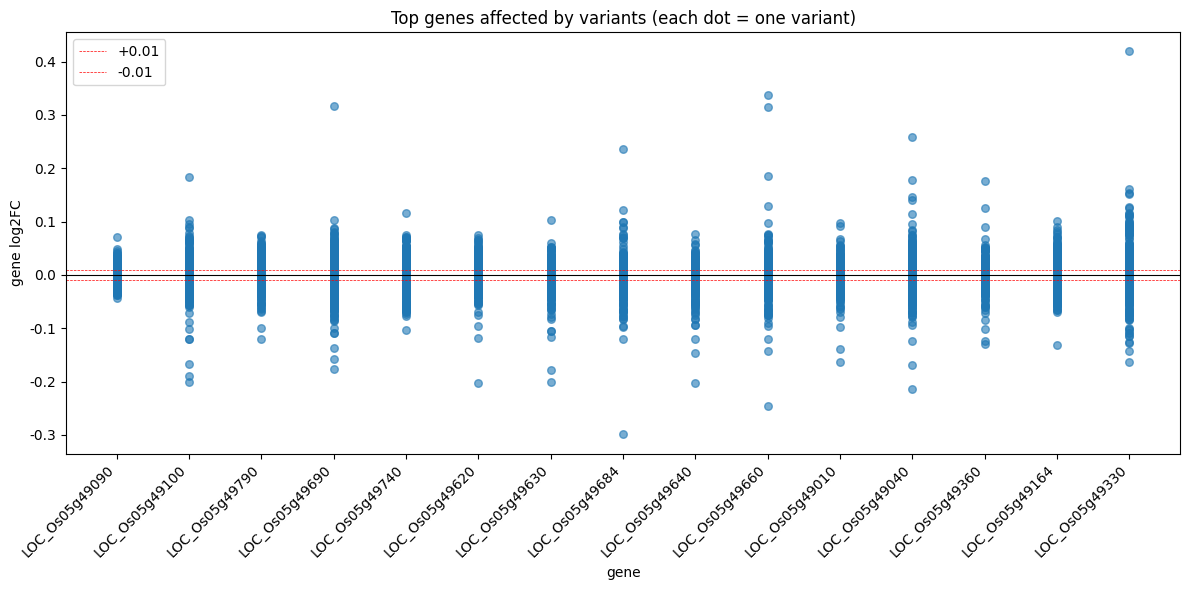

In [70]:
# =====================================================================
# 【筛选 4/4】可视化：每个基因的效应方向与强度（散点 + 阈值线）
# =====================================================================
import matplotlib.pyplot as plt

top_genes = agg[agg["strong_n"] >= 2].head(15).index.tolist()
print("可视化基因：", top_genes)

plt.figure(figsize=(12, 6))
ge_sub = ge[ge["gene"].isin(top_genes)]
plt.scatter(ge_sub["gene"], ge_sub["log2FC"], alpha=0.6, s=30)
plt.axhline(0, color="k", lw=0.8)
plt.axhline(0.01, color="r", ls="--", lw=0.5, label="+0.01")
plt.axhline(-0.01, color="r", ls="--", lw=0.5, label="-0.01")
plt.xticks(rotation=45, ha="right")
plt.ylabel("gene log2FC")
plt.xlabel("gene")
plt.title("Top genes affected by variants (each dot = one variant)")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
res_df['region'].value_counts()

region
intergenic        4385
gene_noncoding    1656
CDS               1226
Name: count, dtype: int64

In [65]:
res_df.to_csv("variant_effect_top20000.csv", index=False)